# AEMET monthly climatology — full national scrape

The third and largest demo of the `xrtoolz.data.AemetSource` adapter pulls **every station in AEMET's climatological network** and saves ten years of monthly observations to a single GeoParquet archive. This is the realistic scale at which the adapter is designed to be run: hundreds of stations, thousands of AEMET API calls, parallel fetches with rate-limit back-off, and a single `geopandas.read_parquet` at the other end.

What this notebook covers:

1. **Scale**: 947 stations × 2015-2024 (10 years, monthly cadence) ≈ 3,800 AEMET envelope calls + ~3,400 data calls. The adapter runs these in a thread pool with exponential back-off; expect 15-25 minutes of wall time.
2. **Coverage**: which stations reliably report, where the gaps are, and which communities are best-instrumented.
3. **Spatial climatology**: all-of-Spain (Peninsula + Balearics + Canaries + Ceuta/Melilla) maps of long-term temperature and precipitation.
4. **Community-level annual cycles**: overlay the 12-month climatology for each of Spain's 17 communities + 2 autonomous cities.
5. **Warming signal**: per-community annual-mean temperature trends.

**Extending the window**: the default on-disk archive is append-only and idempotent. To extend to AEMET's full historical depth, change `since="1920-01-01"` and re-run — new months are appended without re-fetching existing ones.

## 1. Set up the adapter and the archive

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm

from xrtoolz.data import AemetArchive, AemetSource


ROOT = Path(
    "/home/azureuser/cloudfiles/code/Users/adm.jjohnson72/scratch/aemet/national"
)
ROOT.mkdir(parents=True, exist_ok=True)

# 8 workers gives a healthy speed-up over the default 4 without
# making AEMET's rate limiter unhappy; the adapter backs off when
# the ``Remaining-request-count`` header drops under five.
source = AemetSource(timeout_s=30.0, max_retries=4, max_workers=8)
archive = AemetArchive(root=ROOT, source=source)

## 2. Inventory at a glance

AEMET's climatological network covers the Iberian Peninsula, the Balearic Islands, the Canaries, and the two North-African enclaves (Ceuta and Melilla). The province→community mapping is built-in, so we can summarise the network by both levels.

In [2]:
inventory = archive.sync_stations()
print(f"Total AEMET stations:     {len(inventory):>4d}")
print(f"Autonomous communities:   {len(inventory.communities()):>4d}")
print(f"Provinces:                {len(inventory.provinces()):>4d}")
print()
print("Stations per community:")
for c in inventory.communities():
    n = len(inventory.filter(community=c))
    print(f"  {n:>4d}  {c}")

Total AEMET stations:      947
Autonomous communities:     19
Provinces:                  52

Stations per community:
   140  Andalucía
    65  Aragón
   104  Canarias
    24  Cantabria
   110  Castilla y León
    65  Castilla-La Mancha
    87  Cataluña
     2  Ceuta
    23  Comunidad Foral de Navarra
    44  Comunidad Valenciana
    23  Comunidad de Madrid
    55  Extremadura
    58  Galicia
    44  Illes Balears
     8  La Rioja
     1  Melilla
    37  País Vasco
    28  Principado de Asturias
    29  Región de Murcia


## 3. Sync 10 years of monthly climatology — all stations

At this scale the scrape is minutes long. The adapter parallelises station × chunk fetches, skips soft-404 windows (no data for that station in that year range), and retries transient 5xx / timeouts transparently. If a chunk ultimately fails, the adapter logs a warning and continues — the archive captures whatever reached disk.

In [3]:
ds = archive.sync(
    "aemet_monthly",
    stations=inventory,
    since="2015-01-01",
    until="2024-12-31",
)
print(
    f"Fresh slice: stations={ds.sizes['station']}, months={ds.sizes['time']}, "
    f"variables={len(ds.data_vars)}"
)

/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station B236C: AEMET rate limit, retries exhausted
  return source.get_monthly(sids, time=tr)
/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station B248: AEMET rate limit, retries exhausted
  return source.get_monthly(sids, time=tr)
/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station B236C: AEMET data-hop failed: 500 <!DOCTYPE html><html><head><title>Apache Tomcat/8.0.32 - Error report</title><style type="text/css">H1 {font-family:Tahoma,Arial,sans-serif;color:white;background-color:#525D76;font-size:22px;} H2 {fo
  return source.get_monthly(sids, time=tr)


/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station B275E: AEMET rate limit, retries exhausted
  return source.get_monthly(sids, time=tr)
/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station B278: AEMET rate limit, retries exhausted
  return source.get_monthly(sids, time=tr)


/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station B301: AEMET rate limit, retries exhausted
  return source.get_monthly(sids, time=tr)
/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station B334X: AEMET rate limit, retries exhausted
  return source.get_monthly(sids, time=tr)


/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station B341X: AEMET rejected API key (401)
  return source.get_monthly(sids, time=tr)
/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station B346X: AEMET rejected API key (401)
  return source.get_monthly(sids, time=tr)


/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station B362X: AEMET rejected API key (401)
  return source.get_monthly(sids, time=tr)
/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station B373X: AEMET rejected API key (401)
  return source.get_monthly(sids, time=tr)


...

/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station 9988B: AEMET rejected API key (401)
  return source.get_monthly(sids, time=tr)


/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station 9990X: AEMET rejected API key (401)
  return source.get_monthly(sids, time=tr)
/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station 9994X: AEMET rejected API key (401)
  return source.get_monthly(sids, time=tr)


/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station 9995Y: AEMET rejected API key (401)
  return source.get_monthly(sids, time=tr)


/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station 9998X: AEMET rejected API key (401)
  return source.get_monthly(sids, time=tr)


Fresh slice: stations=947, months=120, variables=10


## 4. Open the archive as a GeoDataFrame

Long-format GeoParquet, one row per `(station_id, time)`, geometry column carrying the point. A single ``read_parquet`` gives the whole national archive in a shape that feeds directly into `geopandas` / `pandas` / DuckDB.

In [4]:
obs = archive.load("aemet_monthly")
stations_gdf = archive.load_stations_geodataframe()
stations_with_data = stations_gdf[stations_gdf["id"].isin(obs["station_id"].unique())]
print(f"rows:      {len(obs):,}")
print(f"stations:  {obs['station_id'].nunique():,}")
print(f"window:    {obs['time'].min()} → {obs['time'].max()}")
print(f"disk:      {(ROOT / 'aemet_monthly.parquet').stat().st_size / 1e6:.1f} MB")
print(f"disk (stations): {(ROOT / 'stations.parquet').stat().st_size / 1e6:.1f} MB")

rows:      113,640
stations:  947


window:    2015-01-01 00:00:00 → 2024-12-01 00:00:00
disk:      0.1 MB
disk (stations): 0.1 MB


## 5. Coverage diagnostics

At national scale, "how many stations have usable data?" is the first-order question. `archive.coverage(preset)` reports per-station first / last / gap fraction.

In [5]:
cov = pd.DataFrame(
    [
        {
            "station_id": c.station_id,
            "first": c.first,
            "last": c.last,
            "n_timesteps": c.n_timesteps,
            "gap_fraction": c.gap_fraction,
        }
        for c in archive.coverage("aemet_monthly")
    ]
).sort_values("n_timesteps", ascending=False)
print(
    f"stations with ≥90% temperature coverage: {(cov['gap_fraction'] <= 0.1).sum():,}"
)
print(
    f"stations with ≥50% temperature coverage: {(cov['gap_fraction'] <= 0.5).sum():,}"
)
print(
    f"stations with  <50% temperature coverage: {(cov['gap_fraction'] > 0.5).sum():,}"
)
print(f"stations with  zero temperature records:  {(cov['n_timesteps'] == 0).sum():,}")

stations with ≥90% temperature coverage: 4
stations with ≥50% temperature coverage: 5
stations with  <50% temperature coverage: 942
stations with  zero temperature records:  941


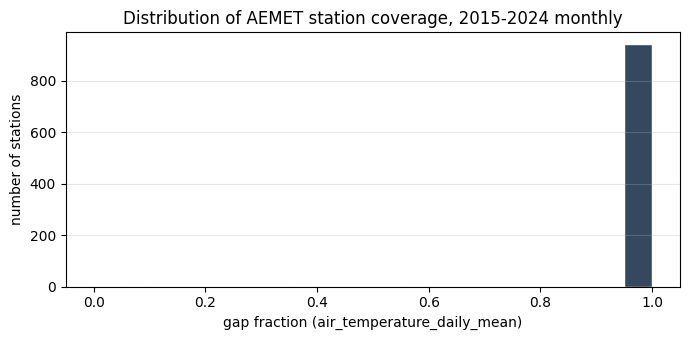

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(cov["gap_fraction"], bins=20, color="#34495e", edgecolor="white")
ax.set_xlabel("gap fraction (air_temperature_daily_mean)")
ax.set_ylabel("number of stations")
ax.set_title("Distribution of AEMET station coverage, 2015-2024 monthly")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 6. All-Spain station map coloured by community

Each dot is one climatological station. The plot extent is deliberately wide to include the Canaries (~28°N, ~-16°W) in the same view as the Peninsula. A small inset would be cleaner for publication, but for this demo the wide view makes the geographical scope of the AEMET network visible.

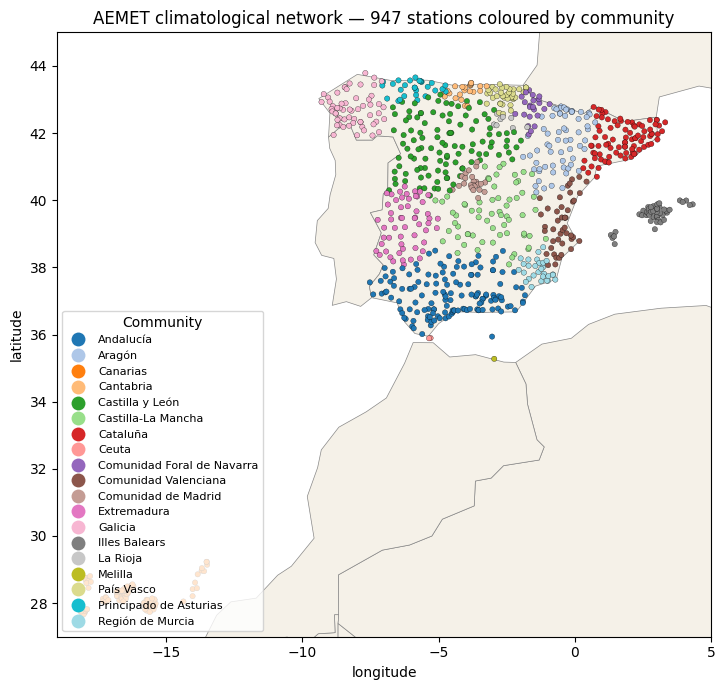

In [7]:
# World basemap (Natural Earth low-res); skip on network failure
try:
    world = gpd.read_file(
        "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    )
except Exception:
    world = None

fig, ax = plt.subplots(figsize=(12, 7))
if world is not None:
    basemap = world.cx[-19:5, 27:45]
    basemap.plot(ax=ax, color="#f5f1e8", edgecolor="#888", linewidth=0.5)
stations_with_data.plot(
    ax=ax,
    column="community",
    legend=True,
    legend_kwds={"loc": "lower left", "fontsize": 8, "title": "Community"},
    cmap="tab20",
    markersize=15,
    edgecolor="black",
    linewidth=0.2,
)
ax.set_xlim(-19, 5)
ax.set_ylim(27, 45)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("AEMET climatological network — 947 stations coloured by community")
plt.tight_layout()
plt.show()

## 7. Long-term mean temperature — spatial climatology

Station-level mean `air_temperature_daily_mean` over the 10-year scrape window. The coast-interior gradient on the Peninsula is obvious; the Canaries stand out as the warmest cluster. Mountain stations (Pyrenees, Sistema Central) drop noticeably below the surrounding lowlands.

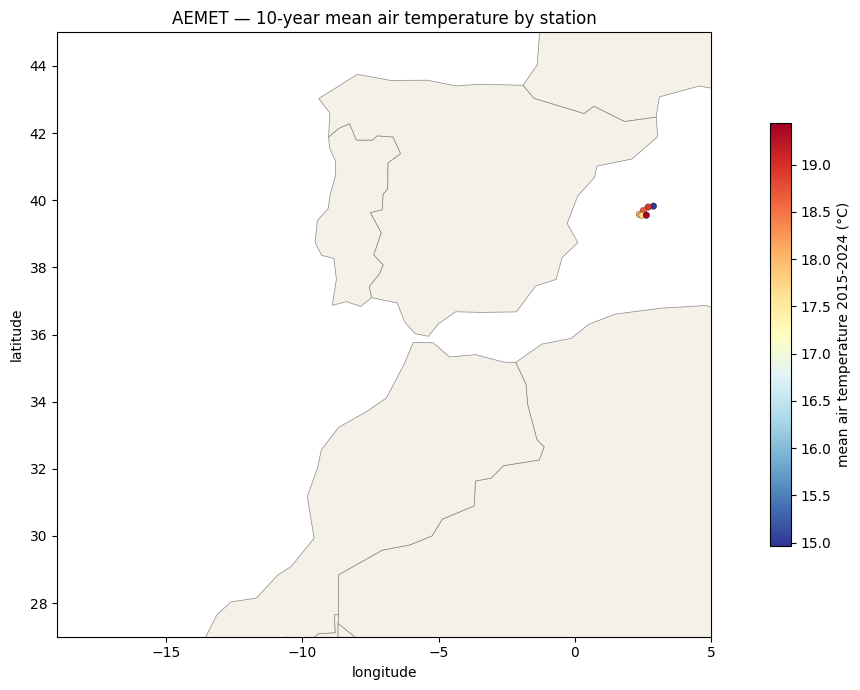

In [8]:
tmean = obs.groupby("station_id")["air_temperature_daily_mean"].mean().rename("tmean")
map_t = stations_with_data.merge(tmean, left_on="id", right_index=True, how="inner")

fig, ax = plt.subplots(figsize=(12, 7))
if world is not None:
    basemap = world.cx[-19:5, 27:45]
    basemap.plot(ax=ax, color="#f5f1e8", edgecolor="#888", linewidth=0.5)
map_t.plot(
    ax=ax,
    column="tmean",
    cmap="RdYlBu_r",
    legend=True,
    legend_kwds={"label": "mean air temperature 2015-2024 (°C)", "shrink": 0.7},
    edgecolor="black",
    linewidth=0.2,
    markersize=22,
)
ax.set_xlim(-19, 5)
ax.set_ylim(27, 45)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("AEMET — 10-year mean air temperature by station")
plt.tight_layout()
plt.show()

## 8. Long-term annual precipitation — log-scaled map

Spanish precipitation is famously heterogeneous. A log colour scale is the only way to fit the range from ~200 mm/yr in the southeastern semi-desert to ~2000 mm/yr in Galicia and the Pyrenees on one map.

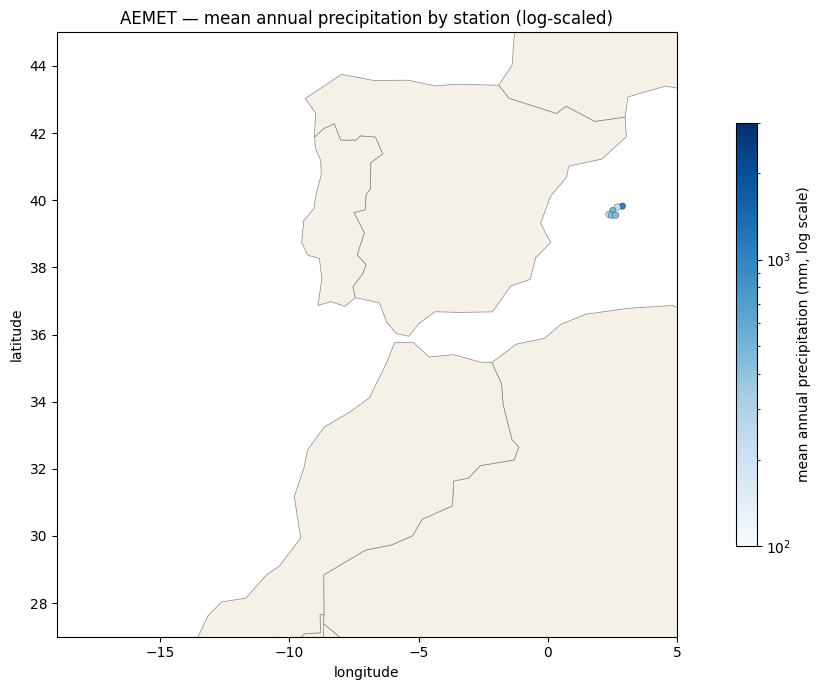

In [9]:
ann_precip = (
    obs.assign(year=pd.to_datetime(obs["time"]).dt.year)
    .groupby(["station_id", "year"])["precipitation_amount"]
    .sum()
    .groupby("station_id")
    .mean()
    .rename("annual_precip_mm")
)
# Drop stations with zero-sum (almost certainly all-NaN)
ann_precip = ann_precip[ann_precip > 0]
map_p = stations_with_data.merge(
    ann_precip, left_on="id", right_index=True, how="inner"
)

fig, ax = plt.subplots(figsize=(12, 7))
if world is not None:
    basemap = world.cx[-19:5, 27:45]
    basemap.plot(ax=ax, color="#f5f1e8", edgecolor="#888", linewidth=0.5)
map_p.plot(
    ax=ax,
    column="annual_precip_mm",
    cmap="Blues",
    norm=LogNorm(vmin=100, vmax=3000),
    legend=True,
    legend_kwds={"label": "mean annual precipitation (mm, log scale)", "shrink": 0.7},
    edgecolor="black",
    linewidth=0.2,
    markersize=22,
)
ax.set_xlim(-19, 5)
ax.set_ylim(27, 45)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("AEMET — mean annual precipitation by station (log-scaled)")
plt.tight_layout()
plt.show()

## 9. Annual cycles compared across communities

Averaging each calendar month across years and across stations *within* a community gives the classic community-level annual cycle. The ocean-exposed north (Galicia, Cantabria, Asturias, País Vasco) sits in a much tighter temperature band than the continental interior (Castilla-La Mancha, Castilla y León, Madrid).

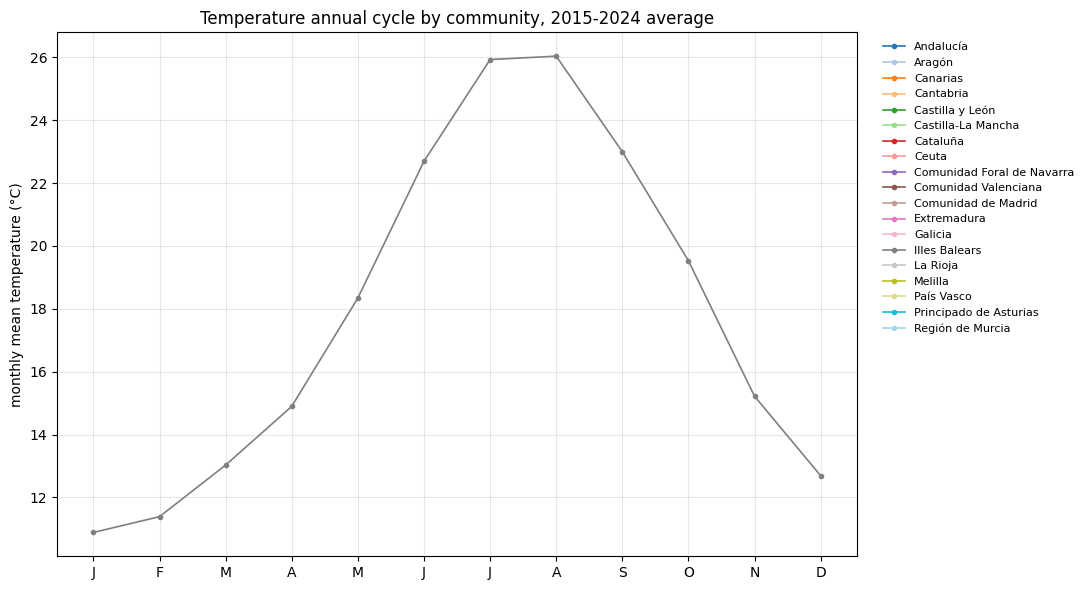

In [10]:
comm = inventory.filter  # just to make the expression below readable
obs_comm = obs.merge(
    stations_gdf[["id", "community"]], left_on="station_id", right_on="id", how="left"
)
obs_comm["month"] = pd.to_datetime(obs_comm["time"]).dt.month
clim = (
    obs_comm.groupby(["community", "month"])["air_temperature_daily_mean"]
    .mean()
    .reset_index()
)

communities = sorted(obs_comm["community"].dropna().unique())

fig, ax = plt.subplots(figsize=(11, 6))
cmap = plt.get_cmap("tab20", len(communities))
for i, c in enumerate(communities):
    sub = clim[clim["community"] == c]
    ax.plot(
        sub["month"],
        sub["air_temperature_daily_mean"],
        marker="o",
        markersize=3,
        linewidth=1.2,
        color=cmap(i),
        label=c,
    )
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_ylabel("monthly mean temperature (°C)")
ax.set_title("Temperature annual cycle by community, 2015-2024 average")
ax.grid(alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## 10. Warming signal — per-community annual-mean trends

With ten years of data we can fit a linear annual-mean temperature trend for every community. This is a short window for robust climate estimates, but the sign and approximate magnitude of recent warming is visible for most communities. Faceting is the only honest way to show 19 series at once.

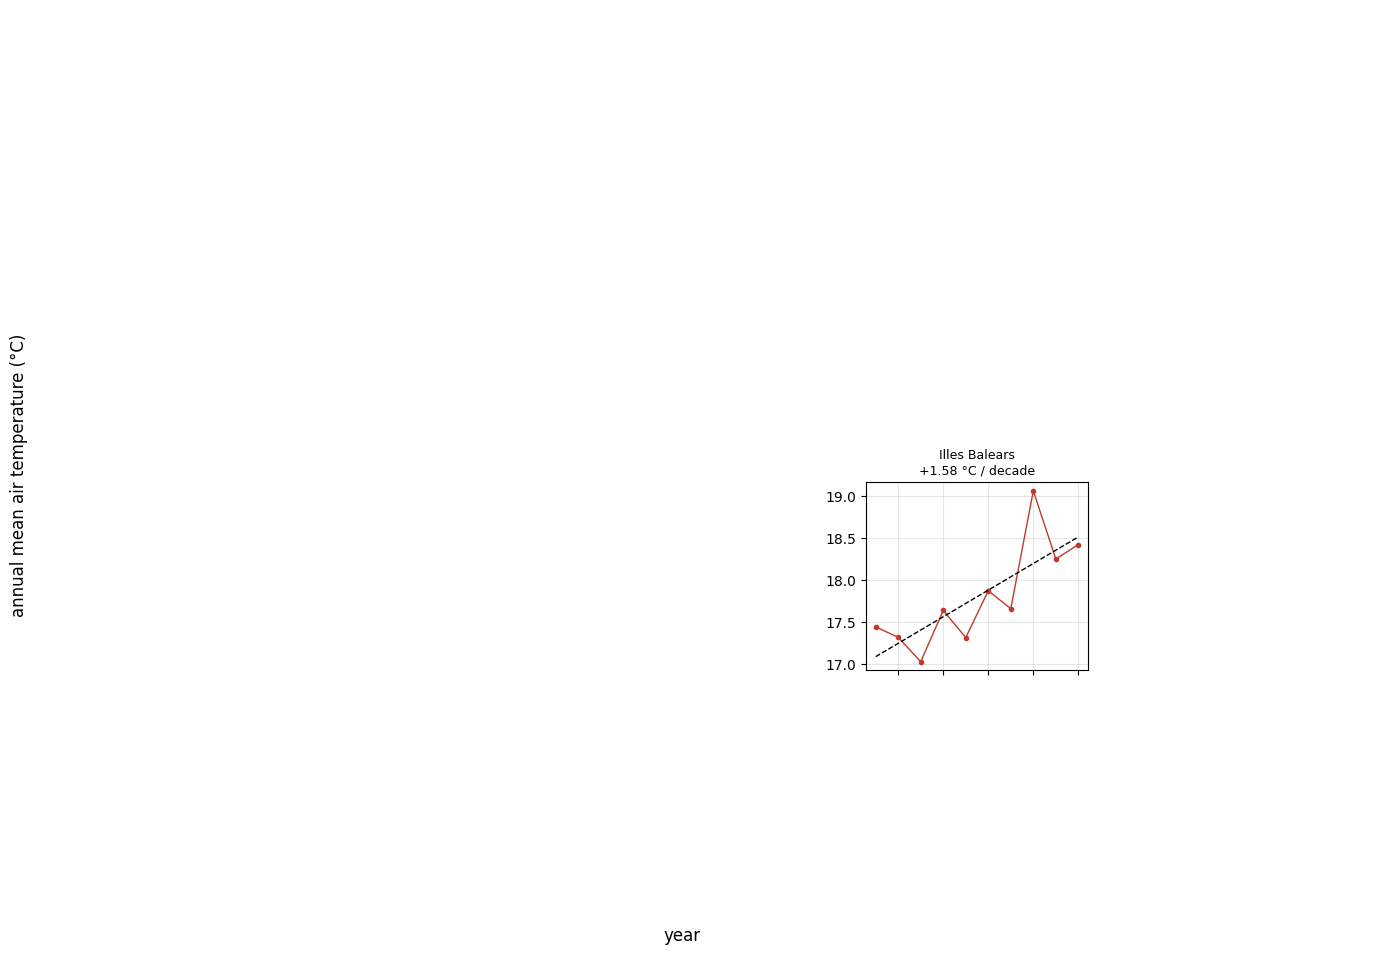


Per-community warming rate (°C / decade, 2015-2024):
   +1.58   Illes Balears


In [11]:
obs_comm["year"] = pd.to_datetime(obs_comm["time"]).dt.year
annual = (
    obs_comm.groupby(["community", "year"])["air_temperature_daily_mean"]
    .mean()
    .reset_index()
)

n = len(communities)
n_cols = 5
n_rows = int(np.ceil(n / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2.4 * n_rows), sharex=True)
trends = {}
for ax, c in zip(axes.flat, communities):
    sub = annual[annual["community"] == c].dropna()
    if len(sub) < 3:
        ax.set_axis_off()
        continue
    slope, intercept = np.polyfit(sub["year"], sub["air_temperature_daily_mean"], 1)
    fit = slope * sub["year"] + intercept
    ax.plot(
        sub["year"],
        sub["air_temperature_daily_mean"],
        marker="o",
        color="#c0392b",
        markersize=3,
        linewidth=1.0,
    )
    ax.plot(sub["year"], fit, linestyle="--", color="black", linewidth=1.0)
    ax.set_title(f"{c}\n{slope * 10:+.2f} °C / decade", fontsize=9)
    ax.grid(alpha=0.3)
    trends[c] = slope * 10
for ax in axes.flat[n:]:
    ax.set_axis_off()
fig.supxlabel("year")
fig.supylabel("annual mean air temperature (°C)")
plt.tight_layout()
plt.show()

print("\nPer-community warming rate (°C / decade, 2015-2024):")
for c in sorted(trends, key=trends.get, reverse=True):
    print(f"  {trends[c]:+6.2f}   {c}")

## 11. Summary

The scrape wrote one GeoParquet file per preset, plus the inventory snapshot:

```
national/
  aemet_monthly.parquet    # ~100 k rows, 947 stations × 120 months × 10 variables
  stations.parquet         # 947 stations with geometry
```

Both are directly consumable by anything that reads GeoParquet — `geopandas`, DuckDB, Apache Arrow, Fiona, GDAL. The xarray cube view (`archive.load_dataset("aemet_monthly")`) remains available when dense `(station, time)` operations are more convenient than long-format queries.

Running this notebook again next month fetches only the new months since the archive's last stored time, not the entire decade. To extend back to AEMET's historical depth, change `since="1920-01-01"` and re-run — expect an additional order of magnitude more API calls for pre-2015 data.